## Rapport Technique de l’SAE 1.02 ( séance TP3-2) : S'initier aux réseaux informatiques - Groupe 10 

### Etudiante : BELGOUR Aicha Soulef

### Sources utilisées pour ce déploiement :

Web (Apache) : Documentation Ubuntu & DigitalOcean

DHCP (ISC) : LinuxTechi

DNS (Bind9) : Linux-Console

### 1. Préparation de l'environnement
Architecture :

Pour que les machines se voient entre elles sans être perturbées par le réseau de l'iut:

on cré les vlans sur Réseau Interne

- Serveur

- Client 


## Installation du Serveur Web (Apache2)

Nous installons le serveur pour héberger le site de l'entreprise.

### 1. Installation

In [ ]:
sudo apt update
sudo apt install apache2 -y

### 2. Autoriser le Pare-feu

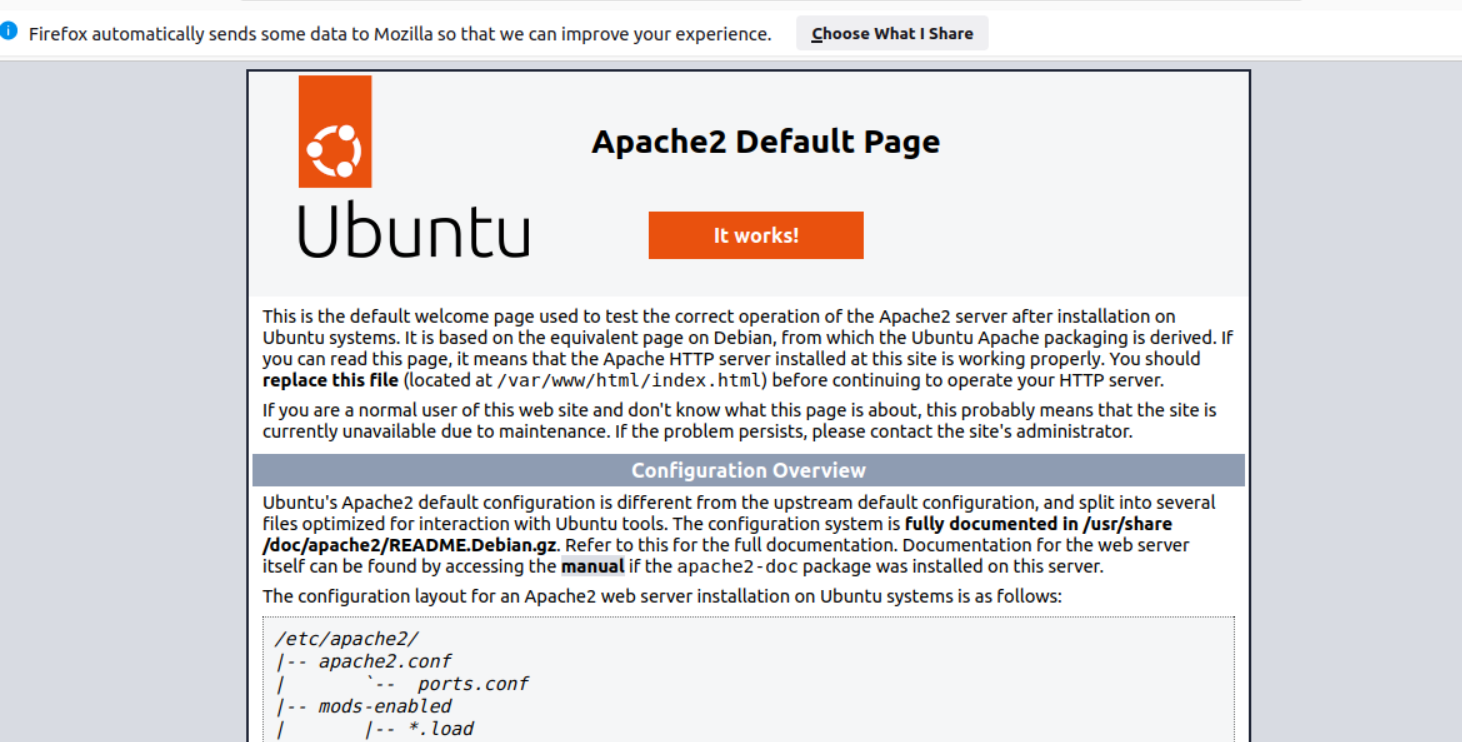

In [ ]:
sudo ufw allow 'Apache'

### 3. Personnaliser la page d'accueil

In [ ]:
sudo nano /var/www/html/index.html

<html>
<head>
  <title>Entreprise groupe10</title>
</head>
<body>
    <h1 style="color:blue;">Bienvenue sur notre Serveur!</h1>
    <p>Site web hébergé sur Apache2</p>
</body>
</html>

### 4. Vérifier que ça tourne

In [ ]:
systemctl status apache2

## Serveur DHCP 

Pour distribuer automatiquement les IP au client

### 1. Installation

In [ ]:
sudo apt install isc-dhcp-server -y


### 2. Définir l'interface d'écoute (On dit au DHCP sur quelle carte envoyer les IP)

In [ ]:
sudo nano /etc/default/isc-dhcp-server

On cherche la ligne INTERFACESv4="" et la modifie :

In [ ]:
INTERFACESv4="enp0s3"


### 3. Configurer le Pool d'IP

In [ ]:
sudo nano /etc/dhcp/dhcpd.conf

Le fichier de configuration a été modifié pour définir les éléments suivants:

Le sous-réseau (Subnet) et la plage d'adresses (Range) à distribuer

La passerelle par défaut (Option routers)

Les serveurs DNS et le nom de domaine

In [ ]:
subnet 192.168.10.0 netmask 255.255.255.0 {
  range 192.168.10.50 192.168.10.150;
  option routers 192.168.10.10;
  option domain-name-servers 192.168.10.10, 8.8.8.8;
  option domain-name "entreprise10.local";
}

### 4. Démarrer le service

In [ ]:
sudo systemctl restart isc-dhcp-server
sudo systemctl status isc-dhcp-server

Vérification client :

Une fois configurés en mode DHCP, les clients reçoivent automatiquement leur configuration réseau après un redémarrage de l'interface

 L'attribution a été vérifiée avec les commandes ip a et nmcli device show

In [ ]:
ip a
nmcli device show

## 3. Serveur DNS

Le service DNS a été implémenté via l'outil dnsmasq
Le fichier de configuration a été édité pour:

- Définir le domaine local

- Associer des noms d'hôtes à des adresses IP

- Activer la résolution DNS locale

In [ ]:
sudo apt install dnsmasq

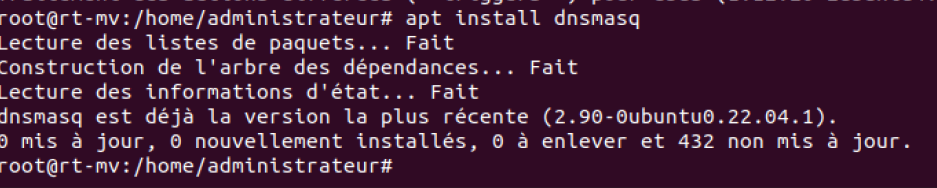

Tests de résolution
Les tests ont été effectués depuis un client en consultant le fichier /etc/resolv.conf et en utilisant l'utilitaire resolvectl status

In [ ]:
cat /etc/resolv.conf
resolvectl status

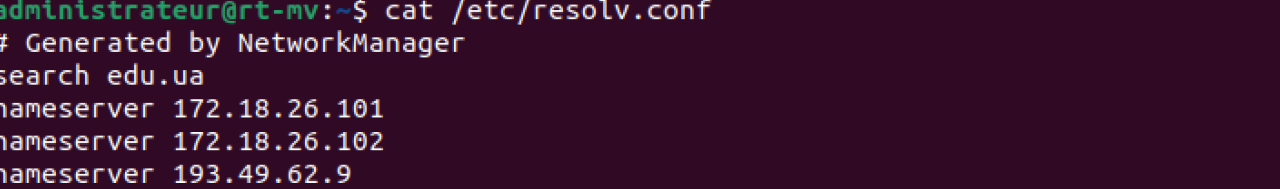
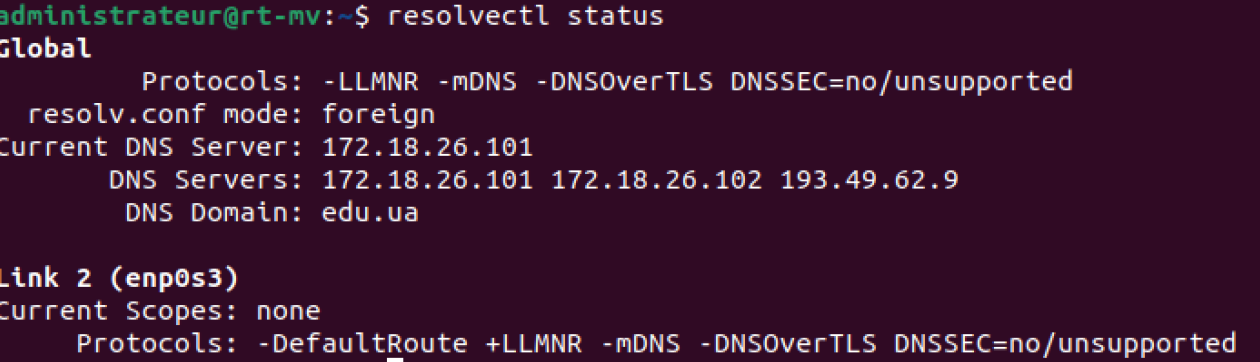

### Preuves de fonctionnement (Captures Wireshark)
Pour valider, des captures de trames ont été réalisées sur l'interface

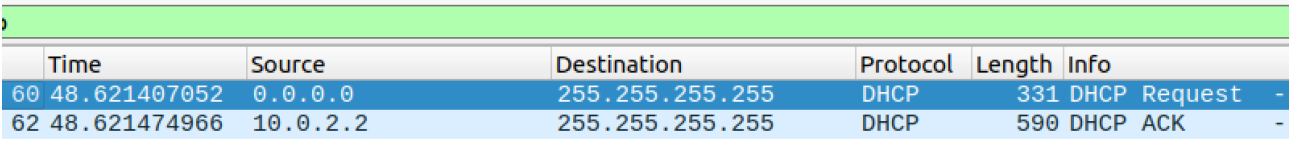


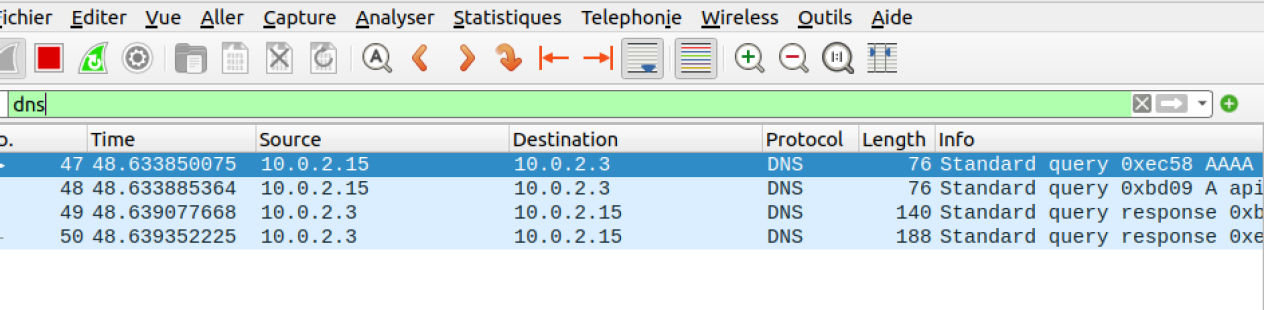
